# 04 `fpos` Model Progression

This notebook started as the main positive result of the thesis, but the **20-seed recording-disjoint sweep (`42` to `61`)** changes the tone. `fpos` still has several strong transfer recipes, yet the aggregate result is no longer “one universal best recipe”.

Unless otherwise noted, the benchmark tables below report those 20 seeds and the diagnostics pool the saved holdout predictions across the same splits.

**Questions answered here**
- Which `fpos` recipes actually survive the 20-seed sweep?
- Which split compositions and paired families favor which model?
- Which ablation blocks mattered most?
- Which structural differences across the paired datasets help explain those preferences?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (
            (candidate / "src" / "qc_thesis" / "__init__.py").exists()
            and (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()


def show_saved_figure(path, caption=None):
    figure_path = Path(path)
    if not figure_path.is_absolute():
        figure_path = (ROOT / figure_path).resolve()
    if not figure_path.exists():
        display(Markdown(f"_Missing figure: `{figure_path}`_"))
        return
    if caption:
        display(Markdown(caption))
    display(Image(filename=str(figure_path)))

fig_dir, table_dir = notebook_output_dirs("04_fpos_model_progression")
benchmark = build_benchmark_progress_table("fpos", scope="core")
ablation_winners = build_ablation_winner_table("fpos")
wave_ids = ["fpos_paired_context", "fpos_context_stack", "fpos_pre_waveform_unlabeled", "fpos_waveform_winner"]
family_pref_ids = ["fpos_paired_raw", *wave_ids]
seed_ids = ["fpos_paired_raw", *wave_ids]
waves = build_main_wave_summary("fpos", wave_ids)
seed_story = build_split_regime_bundle("fpos", seed_ids, split_profile_recipe_id="fpos_waveform_winner")
family_preference = build_fpos_lofo_main_family_preference_table()
family_context = build_family_structure_context_table("fpos", wave_ids)
winner_diag = build_prediction_diagnostics("fpos_waveform_winner", "fpos")
limitations = get_limitations_bundle()


## 1. Benchmark ladder

The main-text `fpos` ladder is intentionally compressed to the core comparison set: baseline floor, target-only reference, source-only transfer, context-first stacking, unlabeled structure, and waveform augmentation. It should be read as a methodological progression rather than as an exhaustive recipe catalog.


In [2]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer", "delta_mae_vs_basic_transfer", "notes"]])
save_table(benchmark, table_dir, "fpos_benchmark_ladder")
fig, _ = plot_benchmark_metric(benchmark, metric="r2", title="`fpos` benchmark ladder by R² (20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fpos_benchmark_r2")
fig


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.196680,0.249872,-0.056857,-0.015538,0.000000,1.759308,-0.096701,Sanity floor
0,Paired-only raw,0.130420,0.184141,0.420881,-0.004587,0.869209,2.237046,-0.162961,Small paired baseline
0,Hybrid-only XGBoost,0.293381,0.401849,-1.816165,0.208963,0.257425,0.000000,0.000000,Pure source failure baseline
0,Paired-only context,0.133729,0.184576,0.418754,-0.009079,0.896552,2.234919,-0.159652,Context-only target baseline
0,Context-first source stack,0.132890,0.187184,0.397283,-0.014800,0.941576,2.213448,-0.160491,Best pre-unlabeled context-first stack
0,Trust-filtered unlabeled stack,0.130187,0.185495,0.406762,-0.018787,1.002887,2.222927,-0.163194,Strongest positive result before waveform embe...
0,Waveform-augmented stack,0.131699,0.187691,0.390605,-0.019935,0.980994,2.206770,-0.161681,Final fpos waveform-augmented stack


<Figure size 1470x630 with 1 Axes>

In [3]:
fig, _ = plot_benchmark_metric(benchmark, metric="mae", title="`fpos` benchmark ladder by MAE (20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fpos_benchmark_mae")
fig


<Figure size 1470x630 with 1 Axes>

In [4]:
milestone = pd.DataFrame([
    {"stage": "1  sanity floor", "model": "Dummy paired mean", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_dummy", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_dummy", "mae"].iloc[0])},
    {"stage": "2  paired baseline", "model": "Paired-only raw", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_paired_raw", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_paired_raw", "mae"].iloc[0])},
    {"stage": "3  source transfer", "model": "Hybrid-only XGBoost", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_only", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_only", "mae"].iloc[0])},
    {"stage": "4  paired context", "model": "Paired-only context", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_paired_context", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_paired_context", "mae"].iloc[0])},
    {"stage": "5  context stacking", "model": "Context-first source stack", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_context_stack", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_context_stack", "mae"].iloc[0])},
    {"stage": "6  + unlabeled paired", "model": "Trust-filtered unlabeled stack", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_pre_waveform_unlabeled", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_pre_waveform_unlabeled", "mae"].iloc[0])},
    {"stage": "7  + waveform embedding", "model": "Waveform-augmented stack", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fpos_waveform_winner", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fpos_waveform_winner", "mae"].iloc[0])},
])
display(milestone)
save_table(milestone, table_dir, "fpos_milestone_trajectory")


,stage,model,r2,mae
0,1 sanity floor,Dummy paired mean,-0.056857,0.196680
1,2 paired baseline,Paired-only raw,0.420881,0.130420
2,3 source transfer,Hybrid-only XGBoost,-1.816165,0.293381
3,4 paired context,Paired-only context,0.418754,0.133729
4,5 context stacking,Context-first source stack,0.397283,0.132890
5,6 + unlabeled paired,Trust-filtered unlabeled stack,0.406762,0.130187
6,7 + waveform embedding,Waveform-augmented stack,0.390605,0.131699


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_milestone_trajectory.csv')

These violin panels summarize the 20 recording-disjoint splits (`42` to `61`) for the retained compared `fpos` models after omitting the dummy and pure source-only baselines, so the thesis can separate one favorable split from the overall stability pattern.

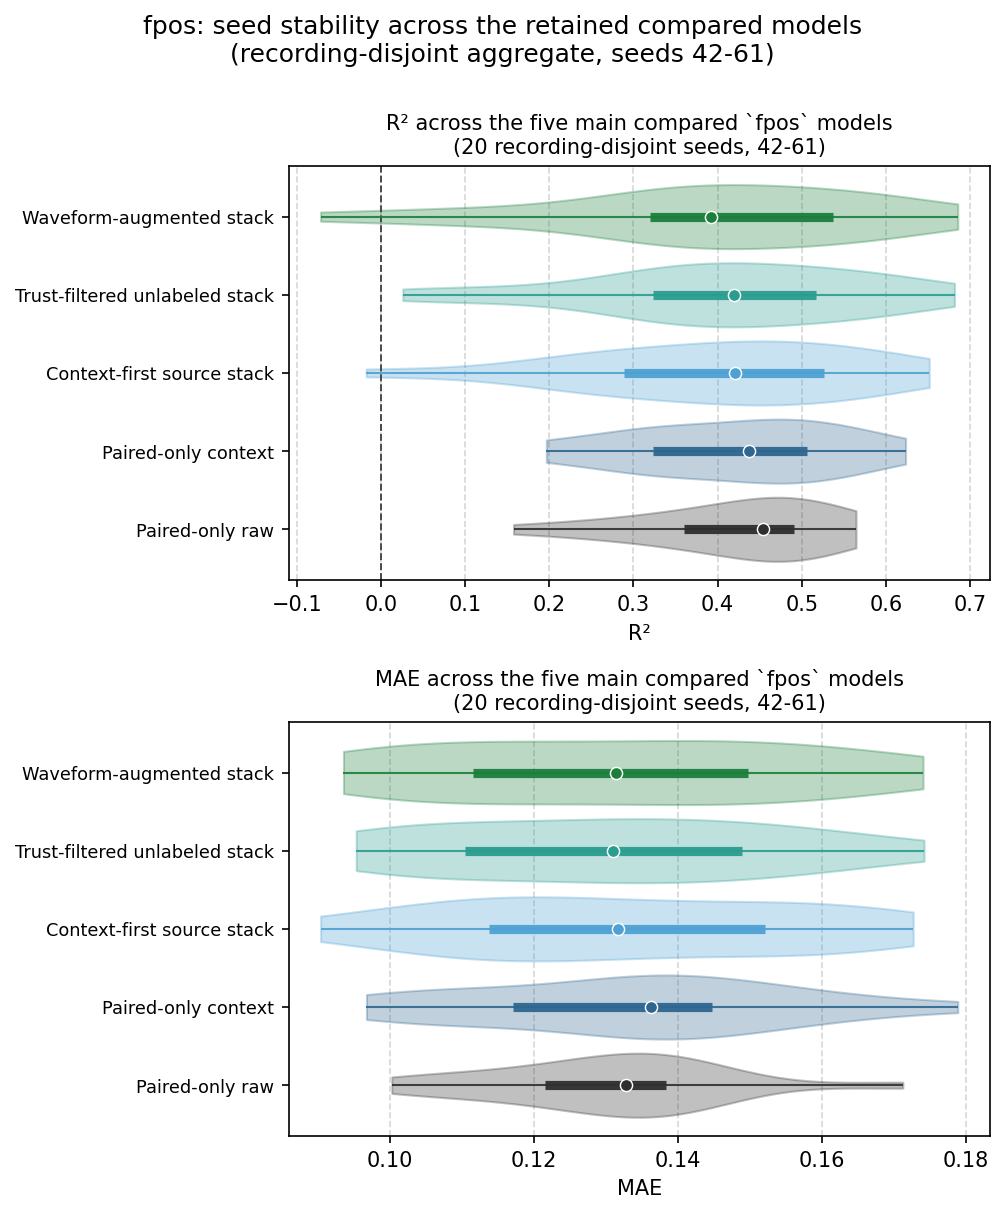

The milestone trajectory makes the asymmetry of the two targets visible: later transfer additions produce much larger gains for `fpos` than for `fmiss`.

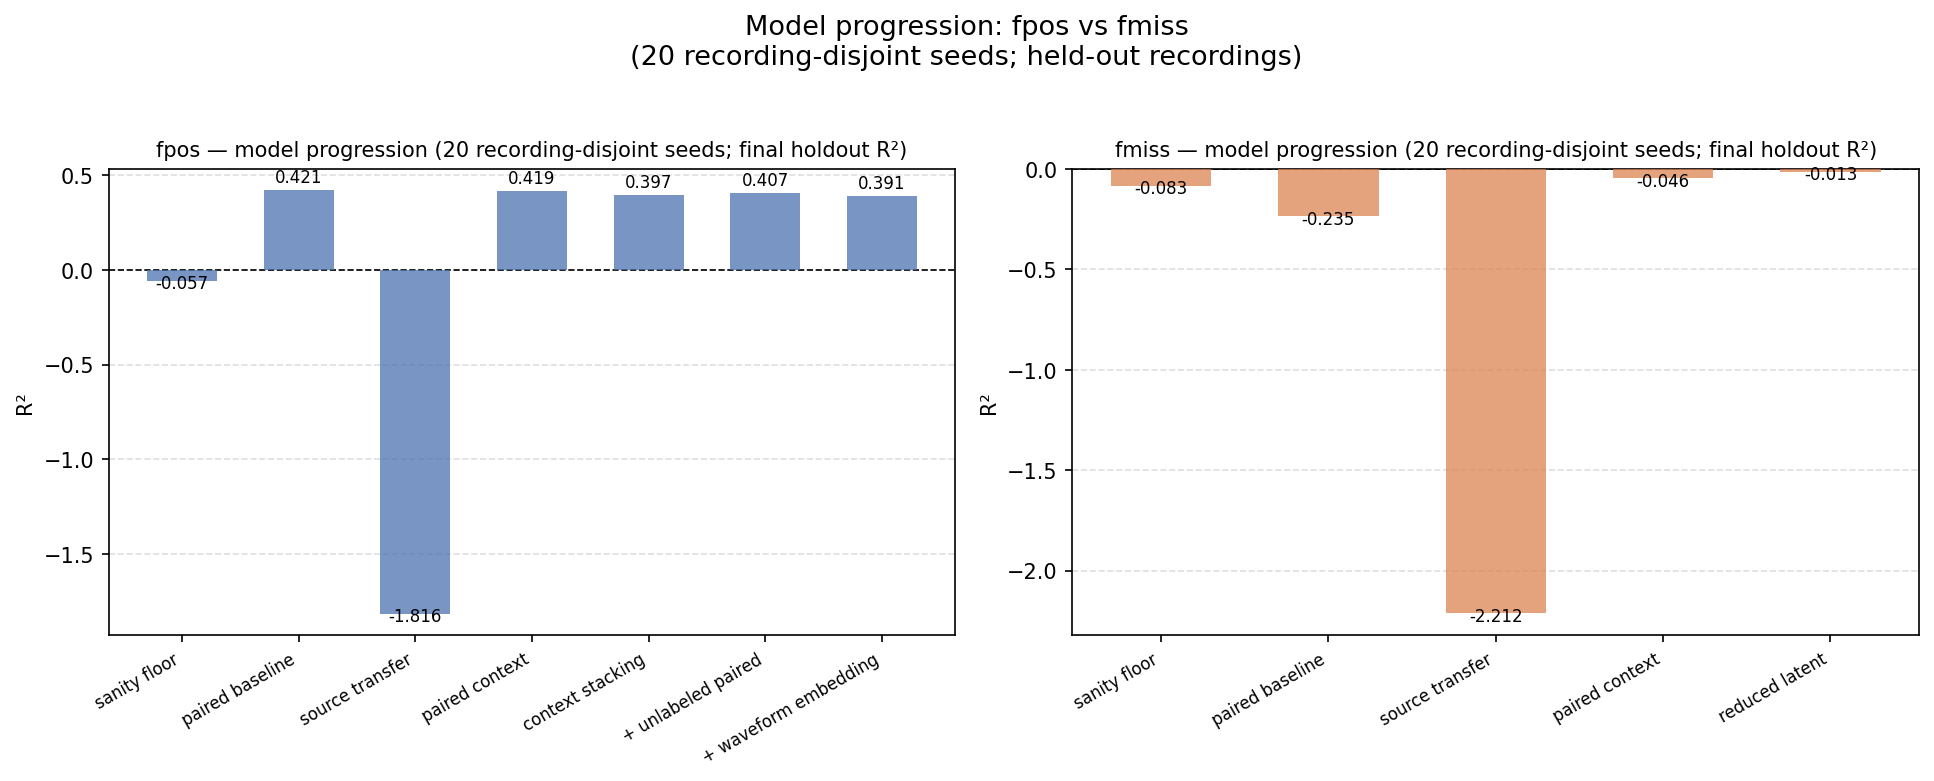

In [5]:
show_saved_figure(
    fig_dir / "fpos_seed_stability.png",
    "These violin panels summarize the 20 recording-disjoint splits (`42` to `61`) for the retained compared `fpos` models after omitting the dummy and pure source-only baselines, so the thesis can separate one favorable split from the overall stability pattern.",
)
show_saved_figure(
    fig_dir / "fpos_fmiss_milestone_trajectory.png",
    "The milestone trajectory makes the asymmetry of the two targets visible: later transfer additions produce much larger gains for `fpos` than for `fmiss`.",
)


In [6]:
top_mean_row = benchmark.sort_values(["r2", "mae"], ascending=[False, True]).iloc[0]
source_only_row = benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_only"].iloc[0]
best_rank_row = seed_story["summary"].iloc[0]
waveform_rank_row = seed_story["summary"].loc[seed_story["summary"]["recipe_id"] == "fpos_waveform_winner"].iloc[0]
display(Markdown(
    f"""
## Main 20-seed read

- The source-only transfer baseline reaches **R² {source_only_row['r2']:.4f}**.
- The best **mean R²** in the full ladder is **{top_mean_row['label']}** at **{top_mean_row['r2']:.4f}**.
- Across the competitive late-wave recipes, the best **mean seed rank** is **{best_rank_row['label']}** (mean rank **{best_rank_row['mean_rank']:.2f}**, **{int(best_rank_row['winner_count'])}** seed wins).
- The recipe named **`Waveform-augmented stack`** is still competitive (mean rank **{waveform_rank_row['mean_rank']:.2f}**, **{int(waveform_rank_row['winner_count'])}** seed wins), but the 20-seed sweep says the story is **regime-dependent rather than dominated by one universally best recipe**.
"""
))



## Main 20-seed read

- The source-only transfer baseline reaches **R² -1.8162**.
- The best **mean R²** in the full ladder is **Paired-only raw** at **0.4209**.
- Across the competitive late-wave recipes, the best **mean seed rank** is **Trust-filtered unlabeled stack** (mean rank **2.40**, **5** seed wins).
- The recipe named **`Waveform-augmented stack`** is still competitive (mean rank **3.25**, **4** seed wins), but the 20-seed sweep says the story is **regime-dependent rather than dominated by one universally best recipe**.


## 2. What survived the 20-seed sweep?

A useful robustness question is not only “who has the highest average `R²`?”, but also “who keeps showing up near the top when the holdout recordings change?”


In [7]:
display(seed_story["summary"])
save_table(seed_story["summary"], table_dir, "fpos_seed_rank_summary")


,recipe_id,label,seed_count,mean_r2,std_r2,min_r2,max_r2,mean_mae,std_mae,mean_rank,median_rank,winner_count,top3_count
0,fpos_pre_waveform_unlabeled,Trust-filtered unlabeled stack,20,0.406762,0.162981,0.025892,0.681585,0.130187,0.022854,2.40,2.5,5,17
1,fpos_context_stack,Context-first source stack,20,0.397283,0.162361,-0.017518,0.651568,0.132890,0.023820,2.85,3.0,4,12
2,fpos_paired_context,Paired-only context,20,0.418754,0.119610,0.196505,0.623438,0.133729,0.021060,3.15,3.0,3,11
3,fpos_waveform_winner,Waveform-augmented stack,20,0.390605,0.184944,-0.071819,0.685462,0.131699,0.024833,3.25,3.0,4,11
4,fpos_paired_raw,Paired-only raw,20,0.420881,0.107311,0.157530,0.564512,0.130420,0.015701,3.35,4.0,4,9


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_seed_rank_summary.csv')

In [8]:
import matplotlib.pyplot as plt

rank_pivot = seed_story["rank_pivot"].copy()
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(rank_pivot.to_numpy(dtype=float), cmap="YlGn_r", vmin=1, vmax=max(len(rank_pivot), 1), aspect="auto")
ax.grid(False)
ax.set_xticks(range(rank_pivot.shape[1]))
ax.set_xticklabels(rank_pivot.columns.astype(str).tolist(), rotation=0)
ax.set_yticks(range(rank_pivot.shape[0]))
ax.set_yticklabels(rank_pivot.index.tolist())
ax.set_xlabel("Recording-disjoint seed")
ax.set_title("Rank by seed across the five main compared `fpos` models\n(20 recording-disjoint seeds, 42-61; 1 = best `R²`)", pad=10)
for row_idx, row_label in enumerate(rank_pivot.index):
    for col_idx, col_label in enumerate(rank_pivot.columns):
        value = rank_pivot.loc[row_label, col_label]
        if pd.notna(value):
            ax.text(col_idx, row_idx, int(value), ha="center", va="center", fontsize=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Rank")
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_seed_rank_heatmap")
fig


<Figure size 1400x532 with 2 Axes>

In [9]:
display(seed_story["winner_table"][[
    "seed",
    "label",
    "r2",
    "mae",
    "true_mean",
    "true_std",
    "rows__PAIRED_BOYDEN",
    "rows__PAIRED_CRCNS_HC1",
    "rows__PAIRED_ENGLISH",
    "rows__PAIRED_KAMPFF",
    "rows__PAIRED_MEA64C_YGER",
]])
display(seed_story["winner_profile"])
save_table(seed_story["winner_table"], table_dir, "fpos_seed_winner_by_split")
save_table(seed_story["winner_profile"], table_dir, "fpos_seed_winner_profile")


,seed,label,r2,mae,true_mean,true_std,rows__PAIRED_BOYDEN,rows__PAIRED_CRCNS_HC1,rows__PAIRED_ENGLISH,rows__PAIRED_KAMPFF,rows__PAIRED_MEA64C_YGER
0,42,Waveform-augmented stack,0.533189,0.116062,0.220910,0.247669,21.0,9.0,44.0,6.0,20.0
1,43,Paired-only raw,0.532105,0.128534,0.236327,0.252522,5.0,14.0,53.0,12.0,16.0
2,44,Paired-only context,0.501012,0.140482,0.208052,0.251661,22.0,16.0,39.0,6.0,17.0
3,45,Waveform-augmented stack,0.685462,0.107011,0.240260,0.258261,10.0,14.0,39.0,18.0,19.0
4,46,Paired-only raw,0.455852,0.137328,0.222718,0.254777,16.0,15.0,50.0,0.0,19.0
5,47,Waveform-augmented stack,0.626220,0.098870,0.246309,0.239572,26.0,1.0,48.0,17.0,8.0
6,48,Trust-filtered unlabeled stack,0.451038,0.110899,0.188857,0.219311,22.0,16.0,25.0,12.0,25.0
7,49,Paired-only raw,0.564512,0.116415,0.273604,0.258194,15.0,7.0,44.0,17.0,17.0
8,50,Trust-filtered unlabeled stack,0.606935,0.095995,0.213599,0.241583,16.0,8.0,34.0,17.0,25.0
9,51,Context-first source stack,0.211545,0.172689,0.275430,0.272111,10.0,8.0,47.0,24.0,11.0


,recipe_id,label,winner_count,mean_true_mean,mean_true_std,mean_true_iqr,share__PAIRED_BOYDEN,share__PAIRED_CRCNS_HC1,share__PAIRED_ENGLISH,share__PAIRED_KAMPFF,share__PAIRED_MEA64C_YGER
0,fpos_pre_waveform_unlabeled,Trust-filtered unlabeled stack,5,0.222274,0.240479,0.290832,0.174,0.0920,0.392000,0.140000,0.202000
1,fpos_waveform_winner,Waveform-augmented stack,4,0.232401,0.246991,0.284940,0.155,0.0950,0.452500,0.160000,0.137500
2,fpos_context_stack,Context-first source stack,4,0.227578,0.245883,0.298583,0.115,0.1325,0.322500,0.192500,0.237500
3,fpos_paired_raw,Paired-only raw,4,0.229710,0.243460,0.316448,0.155,0.0900,0.482500,0.100000,0.172500
4,fpos_paired_context,Paired-only context,3,0.223618,0.246445,0.296164,0.160,0.1500,0.343333,0.153333,0.193333


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_seed_winner_profile.csv')

In [10]:
winner_profile = seed_story["winner_profile"].copy()
share_cols = [col for col in winner_profile.columns if col.startswith("share__")]
share_plot = winner_profile.loc[:, ["label", *share_cols]].copy()
share_plot = share_plot.rename(columns=lambda col: col.replace("share__PAIRED_", "") if col.startswith("share__") else col)
family_cols = [col for col in share_plot.columns if col != "label"]
fig, ax = plt.subplots(figsize=(8, 3.8))
left = np.zeros(len(share_plot), dtype=float)
palette = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#AA3377"]
for color, col in zip(palette, family_cols):
    values = pd.to_numeric(share_plot[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    ax.barh(share_plot["label"], values, left=left, label=col, color=color, alpha=0.9)
    left = left + values
ax.set_xlim(0, 1)
ax.set_xlabel("Mean family share in seeds won by the model")
ax.set_title("Winning models prefer different holdout mixes", pad=10)
ax.legend(title="Held-out family", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_split_winner_family_mix")
fig


<Figure size 1120x532 with 1 Axes>

---
### Thesis highlights — Split regime map and raw-vs-waveform complementarity

_Provenance._ These figures are thesis synthesis artifacts regenerated from frozen tables and aggregated seed metrics. They intentionally sit on top of the notebook analysis rather than replacing the exploratory cells above.

- **Split regime map:** Seeds are ordered by clustered family-share composition rather than by one hand-picked family. The second panel now shows the leading-recipe `R²` together with target difficulty on the same seed order.
- **Raw vs waveform complementarity:** This figure compares `Paired-only raw` against `Waveform-augmented stack` directly at the seed level. The claim is intentionally narrow: waveform gains are regime-dependent and modestly associated with slightly higher KAMPFF share, slightly lower ENGLISH share, and lower target `IQR` rather than with one absolute “waveform-friendly family”.


This synthesis figure keeps the family-composition story in notebook 04, but the ordering is now driven by clustered split composition rather than a single family share.

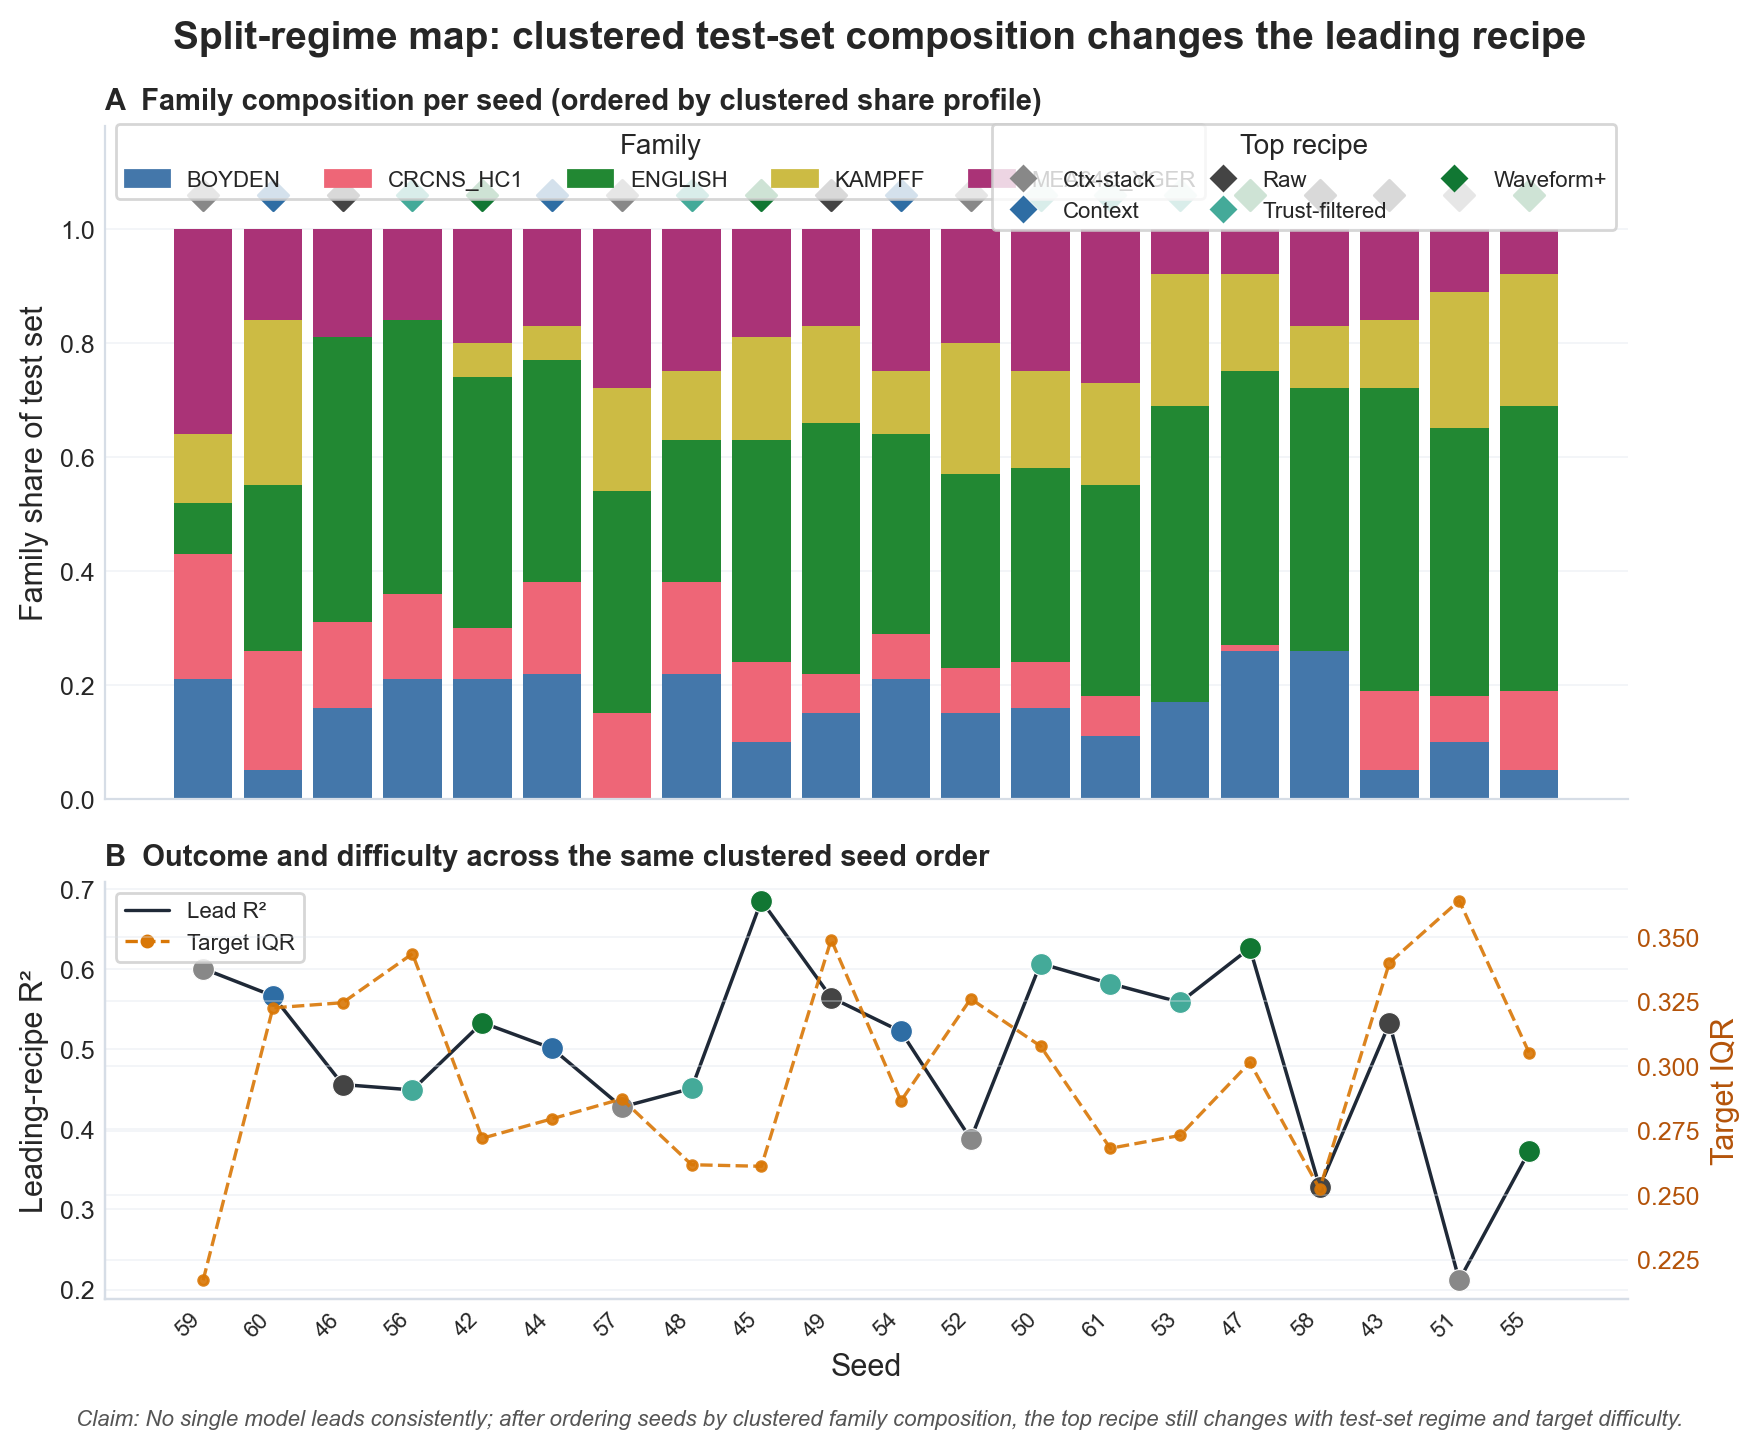

This is the thesis-ready comparison between the simple paired model and the waveform-enhanced stack; it explains complementarity rather than claiming a universal waveform advantage.

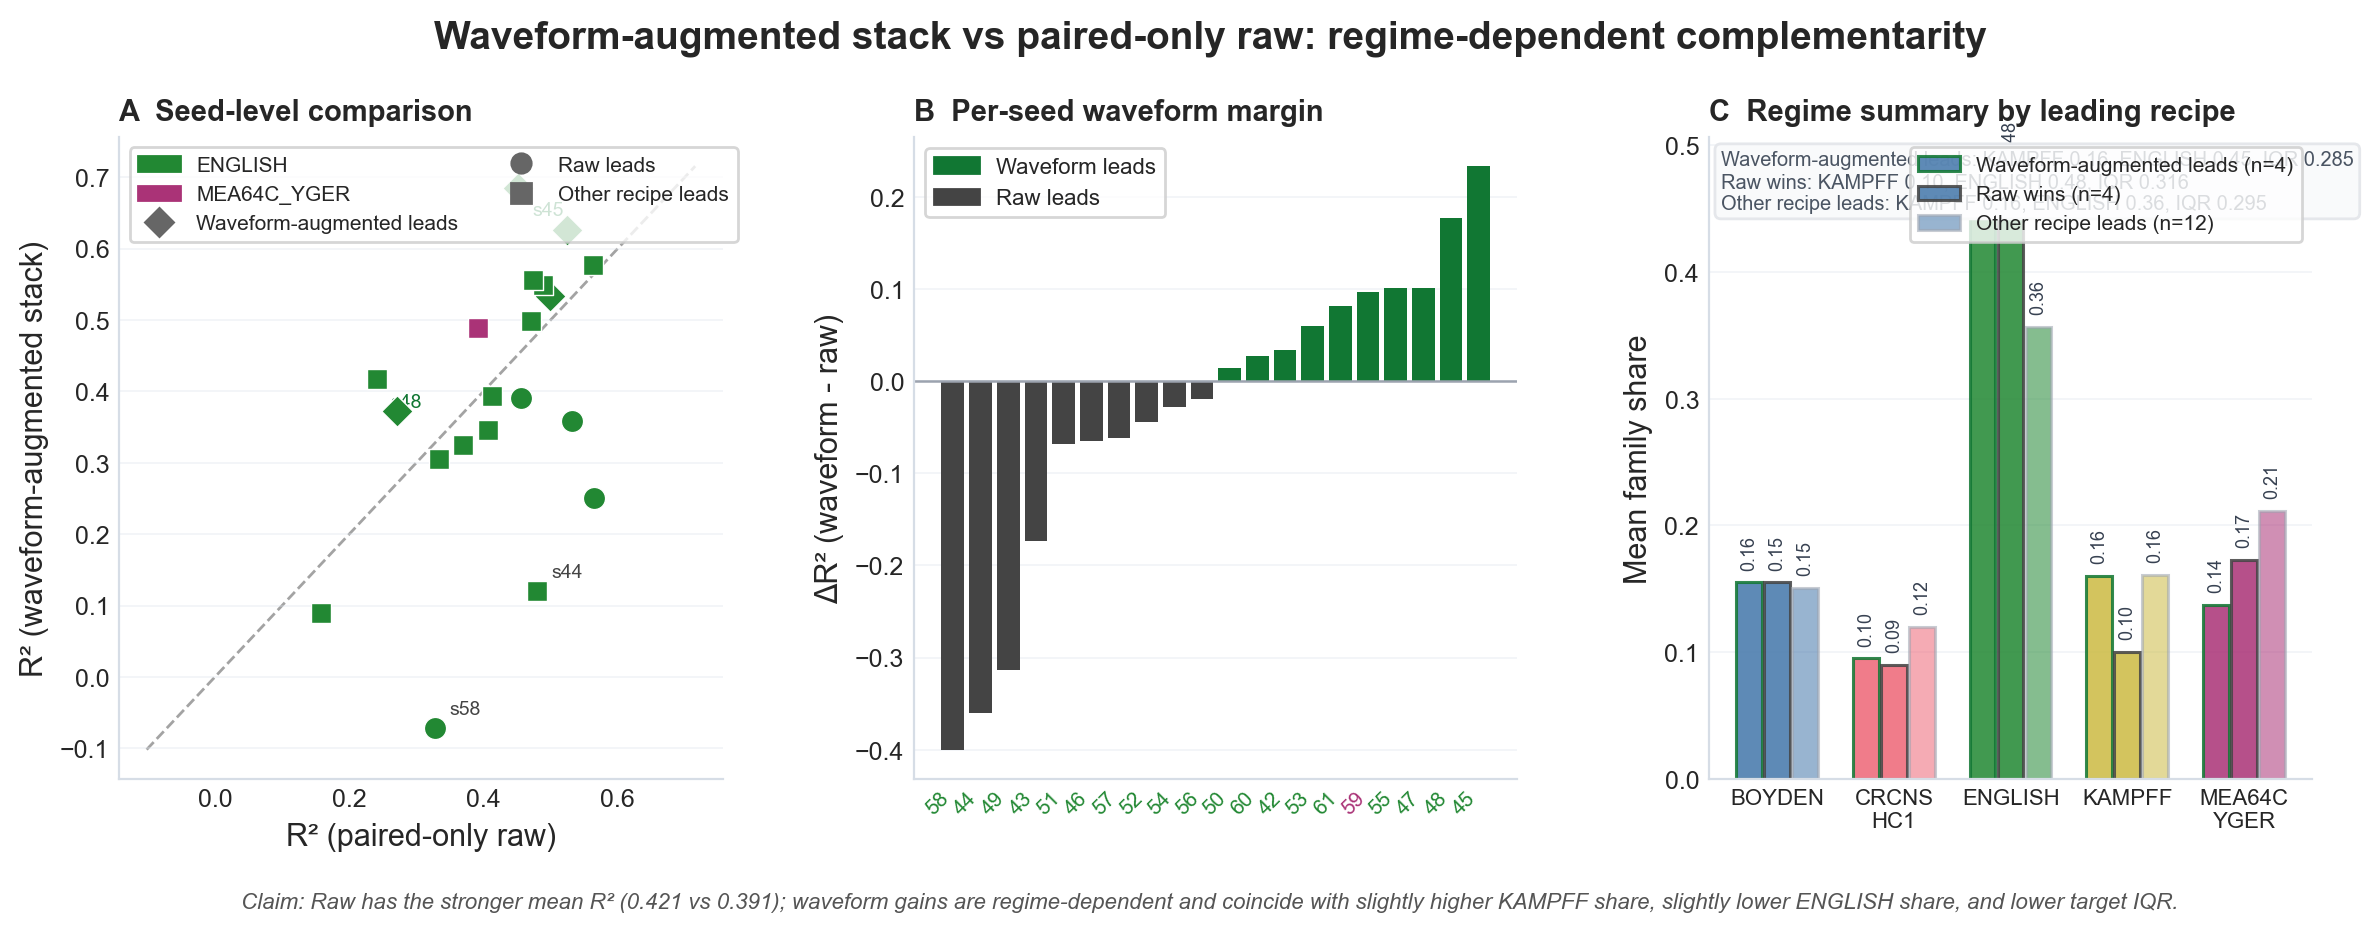

In [11]:
show_saved_figure(
    ROOT / "figures" / "09_thesis_highlight_figures" / "split_regime_map.png",
    "This synthesis figure keeps the family-composition story in notebook 04, but the ordering is now driven by clustered split composition rather than a single family share.",
)
show_saved_figure(
    ROOT / "figures" / "09_thesis_highlight_figures" / "raw_vs_waveform_complementarity.png",
    "This is the thesis-ready comparison between the simple paired model and the waveform-enhanced stack; it explains complementarity rather than claiming a universal waveform advantage.",
)


## 3. Which ablation blocks mattered?

Each ablation group corresponds to one scientific question. The goal is not to show every run equally, but to make the causal story of the leading stack understandable.


In [12]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fpos_ablation_winners")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_supervision,Paired-only raw,fpos_paired_raw,0.420881,0.130420,Small paired baseline
1,context,Paired-only raw,fpos_paired_raw,0.420881,0.130420,Small paired baseline
2,unlabeled_paired_structure,Trust-filtered unlabeled stack,fpos_pre_waveform_unlabeled,0.406762,0.130187,Strongest positive result before waveform embe...
3,waveform_representation,Trust-filtered unlabeled stack,fpos_pre_waveform_unlabeled,0.406762,0.130187,Strongest positive result before waveform embe...
4,robustness,Trust-filtered unlabeled stack,fpos_pre_waveform_unlabeled,0.406762,0.130187,Strongest positive result before waveform embe...


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_ablation_winners.csv')

In [13]:
for group_name in ["source_supervision", "context", "unlabeled_paired_structure", "waveform_representation", "robustness"]:
    bundle = build_ablation_bundle("fpos", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fpos_ablation_{group_name}")


### Source Supervision

,label,mae,r2,notes
0,Dummy paired mean,0.191016,-0.000221,Sanity floor
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Hybrid-only XGBoost,0.251464,-0.925127,Pure source failure baseline


### Context

,label,mae,r2,notes
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Paired-only context,0.132842,0.467458,Context-only target baseline
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack


### Unlabeled Paired Structure

,label,mae,r2,notes
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack
0,Trust-filtered unlabeled stack,0.117866,0.501473,Strongest positive result before waveform embe...


### Waveform Representation

,label,mae,r2,notes
0,Trust-filtered unlabeled stack,0.117866,0.501473,Strongest positive result before waveform embe...
0,Waveform-augmented stack,0.116062,0.533189,Final fpos waveform-augmented stack


### Robustness

,label,mae,r2,notes
0,Trust-filtered unlabeled stack,0.117866,0.501473,Strongest positive result before waveform embe...
0,Waveform-augmented stack,0.116062,0.533189,Final fpos waveform-augmented stack


## 4. Which families prefer which recipe?

The stricter family-held-out view is where the generalization story becomes interpretable. This comparison averages `R²` across `20` leave-one-family-out seeds and is kept aligned with the five main compared `fpos` models, excluding only the dummy and pure source-only baselines.


In [14]:
display(family_preference["best"])
display(family_preference["r2_pivot"])
save_table(family_preference["best"], table_dir, "fpos_lofo_family_preference_best")
save_table(family_preference["r2_pivot"].reset_index(), table_dir, "fpos_lofo_family_preference_r2")


,held_out_family,best_recipe_id,best_label,best_r2,best_mae,family_rank
0,PAIRED_BOYDEN,fpos_waveform_winner,Waveform-augmented stack,0.137973,0.082065,1
1,PAIRED_CRCNS_HC1,fpos_paired_context,Paired-only context,0.448713,0.185990,1
2,PAIRED_ENGLISH,fpos_context_stack,Context-first source stack,0.397894,0.168758,1
3,PAIRED_KAMPFF,fpos_waveform_winner,Waveform-augmented stack,0.712486,0.091113,1
4,PAIRED_MEA64C_YGER,fpos_waveform_winner,Waveform-augmented stack,0.332142,0.071283,1


label,Paired-only raw,Paired-only context,Context-first source stack,Trust-filtered unlabeled stack,Waveform-augmented stack
held_out_family,,,,,
PAIRED_BOYDEN,0.002850,-0.165875,0.111448,0.097687,0.137973
PAIRED_CRCNS_HC1,0.433386,0.448713,0.424923,0.437174,0.427592
PAIRED_ENGLISH,0.203613,0.308621,0.397894,0.387863,0.377425
PAIRED_KAMPFF,0.566184,0.644829,0.689972,0.708892,0.712486
PAIRED_MEA64C_YGER,0.210873,0.260630,0.279044,0.225886,0.332142


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_lofo_family_preference_r2.csv')

In [15]:
import matplotlib.pyplot as plt

family_r2 = family_preference["r2_pivot"].copy()
fig, ax = plt.subplots(figsize=(8.4, 3.8))
im = ax.imshow(family_r2.to_numpy(dtype=float), cmap="RdYlGn", vmin=-0.25, vmax=0.85, aspect="auto")
ax.grid(False)
ax.set_xticks(range(family_r2.shape[1]))
ax.set_xticklabels(family_r2.columns.tolist(), rotation=24, ha="right")
ax.set_yticks(range(family_r2.shape[0]))
ax.set_yticklabels([name.replace("PAIRED_", "") for name in family_r2.index.tolist()])
ax.set_title("Mean held-out-family `R²` across the five main compared `fpos` models\n(20-seed leave-one-family-out aggregate)", pad=10)
for row_idx, family_name in enumerate(family_r2.index):
    for col_idx, label in enumerate(family_r2.columns):
        value = family_r2.loc[family_name, label]
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Mean R²")
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_lofo_family_heatmap")
fig


<Figure size 1176x532 with 2 Axes>

In [16]:
display(Markdown(
    """
**Online context note**

The columns `channel_context`, `duration_context`, and `source_context` below paraphrase the paired-study descriptions from **SpikeForest / eLife 2020 Table 2**. The remaining columns are computed from the local thesis package and the pooled 20-seed outputs.
"""
))
display(family_context[[
    "study_set",
    "source_context",
    "channel_context",
    "duration_context",
    "spikeforest_recordings",
    "packaged_recordings",
    "packaged_labeled_rows",
    "packaged_unlabeled_rows",
    "packaged_recording_fraction_vs_spikeforest",
    "target_mean",
    "target_std",
    "paired_pca_distance_from_hybrid",
    "best_recording_disjoint_label",
    "best_recording_disjoint_r2",
    "best_lofo_label",
    "best_lofo_r2",
]])
save_table(family_context, table_dir, "fpos_family_structure_context")



**Online context note**

The columns `channel_context`, `duration_context`, and `source_context` below paraphrase the paired-study descriptions from **SpikeForest / eLife 2020 Table 2**. The remaining columns are computed from the local thesis package and the pooled 20-seed outputs.


,study_set,source_context,channel_context,duration_context,spikeforest_recordings,packaged_recordings,packaged_labeled_rows,packaged_unlabeled_rows,packaged_recording_fraction_vs_spikeforest,target_mean,target_std,paired_pca_distance_from_hybrid,best_recording_disjoint_label,best_recording_disjoint_r2,best_lofo_label,best_lofo_r2
0,PAIRED_BOYDEN,"mouse cortex, subset of larger probe recordings",32-channel cortical subset,6-10 min,19,4,43,864,0.210526,0.155421,0.124180,12.137681,Trust-filtered unlabeled stack,0.272705,Waveform-augmented stack,0.137973
1,PAIRED_CRCNS_HC1,rat hippocampus,4-6 channel tetrode or single-shank probe,6-12 min,93,4,22,162,0.043011,0.330627,0.310580,10.477650,Paired-only context,0.041141,Trust-filtered unlabeled stack,0.437174
2,PAIRED_ENGLISH,"behaving mouse, multiple regions",4-32 channel juxtacellular / Si probe mix,1-36 min,29,15,71,3080,0.517241,0.312829,0.276986,11.779160,Trust-filtered unlabeled stack,0.185344,Trust-filtered unlabeled stack,0.387863
3,PAIRED_KAMPFF,"mouse cortex, subset of larger probe recordings",32-channel cortical subset,9-20 min,15,4,35,1708,0.266667,0.150554,0.215815,20.551983,Waveform-augmented stack,0.798372,Waveform-augmented stack,0.712486
4,PAIRED_MEA64C_YGER,mouse retina,64-channel MEA subset,5 min,18,4,36,2961,0.222222,0.108317,0.136641,5.225309,Paired-only context,0.384112,Waveform-augmented stack,0.332142


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_family_structure_context.csv')

## 5. Family and recording behavior of the main waves

The thesis should not claim improvement unless it can show that gains are broad. These summaries make it clear whether a new wave improved many recordings or only a handful.


In [17]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fpos_family_wave_summary")
save_table(waves["recording"], table_dir, "fpos_recording_wave_summary")
fig, _, family_pivot = plot_group_metric(waves["family"], group_col="study_set", metric="r2", title="`fpos` family R² by model wave")
save_figure(fig, fig_dir, "fpos_family_r2_by_wave")
save_table(family_pivot, table_dir, "fpos_family_r2_pivot")
fig


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias,seed_count,row_count_std,mae_std,rmse_std,r2_std,bias_std
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN,16.052632,0.085210,0.106427,-0.422536,0.011145,19,6.629072,0.030131,0.035124,1.366245,0.062118
1,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1,12.111111,0.190967,0.234293,0.041141,-0.088691,18,5.248163,0.061261,0.063041,0.665577,0.134684
2,fpos_paired_context,Paired-only context,PAIRED_ENGLISH,40.100000,0.188937,0.234657,0.146974,0.007940,20,10.425450,0.032996,0.034244,0.269176,0.087772
3,fpos_paired_context,Paired-only context,PAIRED_KAMPFF,16.500000,0.068725,0.096634,0.770972,-0.028714,18,6.184658,0.025604,0.031897,0.132851,0.038278
4,fpos_paired_context,Paired-only context,PAIRED_MEA64C_YGER,18.900000,0.072938,0.104508,0.384112,-0.007072,20,7.105632,0.018916,0.032113,0.301341,0.045317
5,fpos_context_stack,Context-first source stack,PAIRED_BOYDEN,16.052632,0.072703,0.095642,0.028805,-0.006632,19,6.629072,0.019503,0.025966,0.419326,0.044706
6,fpos_context_stack,Context-first source stack,PAIRED_CRCNS_HC1,12.111111,0.198608,0.245582,0.019355,-0.118264,18,5.248163,0.081825,0.073755,0.717102,0.130473
7,fpos_context_stack,Context-first source stack,PAIRED_ENGLISH,40.100000,0.188472,0.234792,0.142123,0.000110,20,10.425450,0.042094,0.043661,0.309753,0.096380
8,fpos_context_stack,Context-first source stack,PAIRED_KAMPFF,16.500000,0.065954,0.094890,0.781057,-0.021816,18,6.184658,0.022723,0.027161,0.110974,0.043195
9,fpos_context_stack,Context-first source stack,PAIRED_MEA64C_YGER,18.900000,0.075916,0.121023,0.153587,-0.009821,20,7.105632,0.023142,0.045409,0.688454,0.050525


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias,seed_count,row_count_std,mae_std,rmse_std,r2_std,bias_std
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10.0,0.098559,0.116213,-1.431554,0.024028,10,0.0,0.032604,0.039495,1.669771,0.085282
1,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11.0,0.054845,0.069158,-0.095243,-0.036198,9,0.0,0.007339,0.010346,0.332320,0.027150
2,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1.0,0.310921,0.310921,NaN,-0.310921,12,0.0,0.112146,0.112146,0.000000,0.112146
3,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8.0,0.143141,0.191712,-0.073207,0.014961,11,0.0,0.037589,0.025837,0.300950,0.080985
4,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3.0,0.305757,0.333409,-6.062041,-0.296226,12,0.0,0.086464,0.077706,2.977850,0.108057
5,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7.0,0.117109,0.133878,-1.084521,0.101807,13,0.0,0.047788,0.047437,1.448612,0.057635
6,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3.0,0.134894,0.156476,-4.155398,0.132452,14,0.0,0.082135,0.093061,4.843608,0.085141
7,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6.0,0.252583,0.286169,0.086693,-0.020407,10,0.0,0.034578,0.031631,0.199570,0.077996
8,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6.0,0.197706,0.245722,0.367072,0.096679,10,0.0,0.042005,0.033440,0.161665,0.100322
9,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3.0,0.162040,0.194195,-0.471456,-0.054098,12,0.0,0.051380,0.064395,1.001276,0.117534


<Figure size 1540x630 with 1 Axes>

In [18]:
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(recording_mean[recording_mean["label"] == WAVEFORM_AUGMENTED_LABEL], group_col="recording_key", metric="r2", top_n=12)
focus_recordings = pd.concat([top_rec, bottom_rec], ignore_index=True)["recording_key"].drop_duplicates().tolist()
recording_focus = waves["recording"][waves["recording"]["recording_key"].isin(focus_recordings)].copy()
display(top_rec)
display(bottom_rec)
save_table(top_rec, table_dir, "fpos_top_recordings")
save_table(bottom_rec, table_dir, "fpos_worst_recordings")
fig, _, rec_pivot = plot_group_metric(recording_focus, group_col="recording_key", metric="r2", title="`fpos` recording R² by model wave\n(top/bottom recordings from 20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fpos_top_recording_r2_by_wave")
save_table(rec_pivot, table_dir, "fpos_recording_r2_pivot")
fig


,label,recording_key,r2
0,Waveform-augmented stack,PAIRED_KAMPFF::paired_kampff::2015_09_03_Pair_...,0.897815
1,Waveform-augmented stack,PAIRED_KAMPFF::paired_kampff::2015_09_03_Pair_...,0.785563
2,Waveform-augmented stack,PAIRED_KAMPFF::paired_kampff::c14,0.680725
3,Waveform-augmented stack,PAIRED_KAMPFF::paired_kampff::2014_11_25_Pair_3_0,0.641846
4,Waveform-augmented stack,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.631206
5,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m15_190315_152...,0.305166
6,Waveform-augmented stack,PAIRED_BOYDEN::paired_boyden32c::419_1_7,0.278541
7,Waveform-augmented stack,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.274828
8,Waveform-augmented stack,PAIRED_MEA64C_YGER::paired_mea64c::20170621_pa...,0.256286
9,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.200511


,label,recording_key,r2
0,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m57_191105_161455,-167.443089
1,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m15_190315_150...,-89.754151
2,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m139_200114_19...,-7.069910
3,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m14_190326_155432,-4.593257
4,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m108_191125_17...,-3.183315
5,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m57_191105_141906,-3.048591
6,Waveform-augmented stack,PAIRED_MEA64C_YGER::paired_mea64c::20160415_pa...,-1.821951
7,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m113_191125_20...,-1.188619
8,Waveform-augmented stack,PAIRED_ENGLISH::paired_english::m139_200114_22...,-0.715710
9,Waveform-augmented stack,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.002,-0.578824


<Figure size 1260x1394.4 with 2 Axes>

## 6. Split-specific robustness and diagnostics

The last question is whether the recording-disjoint favorite remains the strongest choice when the split gets harsher. The leave-one-family-out companion table shows that it does not.


In [19]:
lofo_map = {
    "fpos_pre_waveform_unlabeled": "reference_anchor_stack_xgboost",
    "fpos_waveform_winner": "wf_embed_anchor_stack_xgboost",
}
protocol_compare = benchmark.loc[
    benchmark["recipe_id"].isin(["fpos_pre_waveform_unlabeled", "fpos_waveform_winner"]),
    ["recipe_id", "label", "r2", "mae"],
].rename(columns={"r2": "recording_disjoint_r2", "mae": "recording_disjoint_mae"})
lofo_companion = limitations.lofo_aggregate.copy()
lofo_companion["recipe_id"] = lofo_companion["variant_id"].map({value: key for key, value in lofo_map.items()})
protocol_compare = protocol_compare.merge(
    lofo_companion.loc[:, ["recipe_id", "macro_r2", "macro_mae", "weighted_r2", "weighted_mae", "worst_family_r2"]],
    on="recipe_id",
    how="left",
)
protocol_compare["macro_r2_gap"] = protocol_compare["macro_r2"] - protocol_compare["recording_disjoint_r2"]
protocol_compare["weighted_r2_gap"] = protocol_compare["weighted_r2"] - protocol_compare["recording_disjoint_r2"]
display(protocol_compare.sort_values("recording_disjoint_r2", ascending=False))
save_table(protocol_compare, table_dir, "fpos_protocol_regime_preference")

waveform_protocol = pd.DataFrame([
    {
        "model": WAVEFORM_AUGMENTED_LABEL,
        "protocol": "recording_disjoint_main",
        "r2": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "recording_disjoint_r2"].iloc[0]),
        "mae": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "recording_disjoint_mae"].iloc[0]),
        "delta_r2_vs_recording": 0.0,
        "delta_mae_vs_recording": 0.0,
    },
    {
        "model": WAVEFORM_AUGMENTED_LABEL,
        "protocol": "family_disjoint_lofo",
        "r2": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "macro_r2"].iloc[0]),
        "mae": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "macro_mae"].iloc[0]),
        "delta_r2_vs_recording": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "macro_r2_gap"].iloc[0]),
        "delta_mae_vs_recording": float(protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "macro_mae"].iloc[0] - protocol_compare.loc[protocol_compare["recipe_id"] == "fpos_waveform_winner", "recording_disjoint_mae"].iloc[0]),
    },
])
save_table(waveform_protocol, table_dir, "fpos_winner_protocol_comparison")


,recipe_id,label,recording_disjoint_r2,recording_disjoint_mae,macro_r2,macro_mae,weighted_r2,weighted_mae,worst_family_r2,macro_r2_gap,weighted_r2_gap
0,fpos_pre_waveform_unlabeled,Trust-filtered unlabeled stack,0.406762,0.130187,0.371500,0.120946,0.358936,0.123327,0.097687,-0.035262,-0.047826
1,fpos_waveform_winner,Waveform-augmented stack,0.390605,0.131699,0.397524,0.119867,0.381793,0.122260,0.137973,0.006918,-0.008812


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_winner_protocol_comparison.csv')

In [20]:
import matplotlib.pyplot as plt

protocol_plot = protocol_compare.sort_values("recording_disjoint_r2", ascending=False).reset_index(drop=True)
x = np.arange(len(protocol_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - width / 2, protocol_plot["recording_disjoint_r2"], width=width, label="Recording-disjoint mean R²", color="#2E6DA4")
ax.bar(x + width / 2, protocol_plot["macro_r2"], width=width, label="Family-held-out macro R²", color="#CC6677")
ax.set_xticks(x)
ax.set_xticklabels(protocol_plot["label"], rotation=25, ha="right")
ax.set_ylabel("R²")
ax.set_title("Which `fpos` recipe is best depends on the split", pad=10)
ax.legend()
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_protocol_regime_preference")
fig


<Figure size 1120x532 with 1 Axes>

In [21]:
winner_predictions = winner_diag["predictions"]
display(winner_predictions.head(20))
fig, _ = plot_prediction_scatter(winner_predictions, title="Best `fpos` model: observed vs predicted")
save_figure(fig, fig_dir, "fpos_winner_prediction_scatter")
fig


,protocol,target,variant_id,family,backend,row_uid,recording_key,study_set,true,pred,abs_error,recipe_id,label,seed,residual
0,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Iro...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.113636,0.152797,0.039161,fpos_waveform_winner,Waveform-augmented stack,42,0.039161
1,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::JRC...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261381,0.284694,0.023313,fpos_waveform_winner,Waveform-augmented stack,42,0.023313
2,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.112410,0.169673,0.057263,fpos_waveform_winner,Waveform-augmented stack,42,0.057263
3,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.170663,0.196328,0.025665,fpos_waveform_winner,Waveform-augmented stack,42,0.025665
4,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.333333,0.207217,0.126116,fpos_waveform_winner,Waveform-augmented stack,42,-0.126116
5,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.158784,0.099575,0.059209,fpos_waveform_winner,Waveform-augmented stack,42,-0.059209
6,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Klu...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.156687,0.203055,0.046368,fpos_waveform_winner,Waveform-augmented stack,42,0.046368
7,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Mou...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.305322,0.312948,0.007626,fpos_waveform_winner,Waveform-augmented stack,42,0.007626
8,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Spy...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.122581,0.176133,0.053552,fpos_waveform_winner,Waveform-augmented stack,42,0.053552
9,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Tri...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261327,0.288410,0.027083,fpos_waveform_winner,Waveform-augmented stack,42,0.027083


<Figure size 896x868 with 1 Axes>

In [22]:
lofo_companion = limitations.lofo_aggregate[limitations.lofo_aggregate["variant_id"].isin(["reference_anchor_stack_xgboost", "wf_embed_anchor_stack_xgboost"])].copy()
display(lofo_companion)
save_table(lofo_companion, table_dir, "fpos_family_held_out_companion")


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2,family_count,seed_count
0,wf_embed_anchor_stack_xgboost,0.119867,0.397524,0.122260,0.381793,0.137973,0.712486,5,20
1,reference_anchor_stack_xgboost,0.120946,0.371500,0.123327,0.358936,0.097687,0.708892,5,20


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_family_held_out_companion.csv')

In [23]:
best_rank_row = seed_story["summary"].iloc[0]
display(Markdown(
    f"""
## Key takeaways

- The 20-seed sweep does **not** support one universal `fpos` best recipe. The strongest late-wave recipe by mean seed rank is **{best_rank_row['label']}**, and several recipes lead on multiple individual seeds.
- Family structure explains part of that instability: **English dominates local coverage, CRCNS_HC1 is tiny and high-variance, and the packaged subset is an uneven slice of the larger SpikeForest study sets**.
- On the harsher family-held-out protocol, the retained comparison shifts slightly toward **`Waveform-augmented stack`**, even though **{best_rank_row['label']}** remains the stronger robust reference on the recording-disjoint benchmark.
- The waveform-augmented recipe still tracks the target reasonably on pooled holdout predictions (**MAE {winner_diag['mae']:.4f}**, correlation **{winner_diag['correlation']:.3f}**), but it should now be presented as a **regime-specific headline model**, not as an unconditional best recipe.
"""
))



## Key takeaways

- The 20-seed sweep does **not** support one universal `fpos` best recipe. The strongest late-wave recipe by mean seed rank is **Trust-filtered unlabeled stack**, and several recipes lead on multiple individual seeds.
- Family structure explains part of that instability: **English dominates local coverage, CRCNS_HC1 is tiny and high-variance, and the packaged subset is an uneven slice of the larger SpikeForest study sets**.
- On the harsher family-held-out protocol, the retained comparison shifts slightly toward **`Waveform-augmented stack`**, even though **Trust-filtered unlabeled stack** remains the stronger robust reference on the recording-disjoint benchmark.
- The waveform-augmented recipe still tracks the target reasonably on pooled holdout predictions (**MAE 0.1317**, correlation **0.646**), but it should now be presented as a **regime-specific headline model**, not as an unconditional best recipe.
